# Exploratory Data Analysis (EDA) - IMDB Dataset
Notebook này thực hiện các bước EDA cơ bản trên tập dữ liệu IMDB Dataset để giải quyết Câu A1 và Câu A2.

## Khai báo thư viện cần thiết


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
import nltk


# Câu A1 : Tải dữ liệu và mô hình cấu trúc DataFrame


In [2]:
# 1. Tải dữ liệu
df = pd.read_csv('data/IMDB Dataset.csv')

# 2. Hiển thị 10 dòng đầu
print("10 dòng đầu của dữ liệu:")
display(df.head(10))

10 dòng đầu của dữ liệu:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [3]:
# 3. Kích thước và kiểu dữ liệu từng cột
print(f"Kích thước DataFrame: {df.shape[0]} dòng, {df.shape[1]} cột\n")
print("--- Kiểu dữ liệu từng cột ---")
df.info()

Kích thước DataFrame: 50000 dòng, 2 cột

--- Kiểu dữ liệu từng cột ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [4]:
print("--- Số lượng mẫu theo từng nhãn ---")
sl_tung_nhan = df['sentiment'].value_counts()
print(sl_tung_nhan)

print("\n--- Tỷ lệ phần trăm từng nhãn ---")
# 1. Tính tổng số lượng tất cả các dòng dữ liệu
tong_so_mau = len(df)

# 2. Lấy số lượng từng nhãn chia cho tổng số mẫu, rồi nhân 100
phan_tram = (sl_tung_nhan / tong_so_mau) * 100

print(phan_tram)

--- Số lượng mẫu theo từng nhãn ---
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

--- Tỷ lệ phần trăm từng nhãn ---
sentiment
positive    50.0
negative    50.0
Name: count, dtype: float64


### Nhận xét
- Cấu trúc dữ liệu: Tập dữ liệu có tổng cộng 50.000 dòng và 2 cột là review (chứa nội dung đánh giá) và sentiment (chứa nhãn cảm xúc).
- Về tính mất cân bằng: Tập dữ liệu này hoàn toàn cân bằng (perfectly balanced). Nhãn positive (Tích cực) chiếm chính xác 50% (25.000 mẫu) và nhãn negative (Tiêu cực) cũng chiếm 50% (25.000 mẫu).
- Dữ liệu bị mất cân bằng sẽ ảnh hưởng :
Nếu một nhãn chiếm tỷ lệ quá lớn (ví dụ 90% Tích cực, 10% Tiêu cực), mô hình AI học trên dữ liệu đó sẽ sinh ra tính lười biếng và "thiên vị" (bias). Nó chỉ cần đoán bừa mọi kết quả đều là "Tích cực" thì độ chính xác vẫn đạt 90%, dẫn đến việc nó mất đi khả năng nhận diện lớp thiểu số.

## Câu A2: Tính toán thống kê và phân phối độ dài văn bản

--- Thống kê độ dài văn bản theo nhãn ---


word_count                                                    \
               count       mean         std   min    25%    50%    75%   
sentiment                                                                
negative     25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0   
positive     25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0   

                  char_count                                               \
              max      count        mean          std   min    25%    50%   
sentiment                                                                   
negative   1522.0    25000.0  1294.06436   945.892669  32.0  706.0  973.0   
positive   2470.0    25000.0  1324.79768  1031.492627  65.0  691.0  968.0   

                             
               75%      max  
sentiment                    
negative   1567.25   8969.0  
positive   1614.00  13704.0

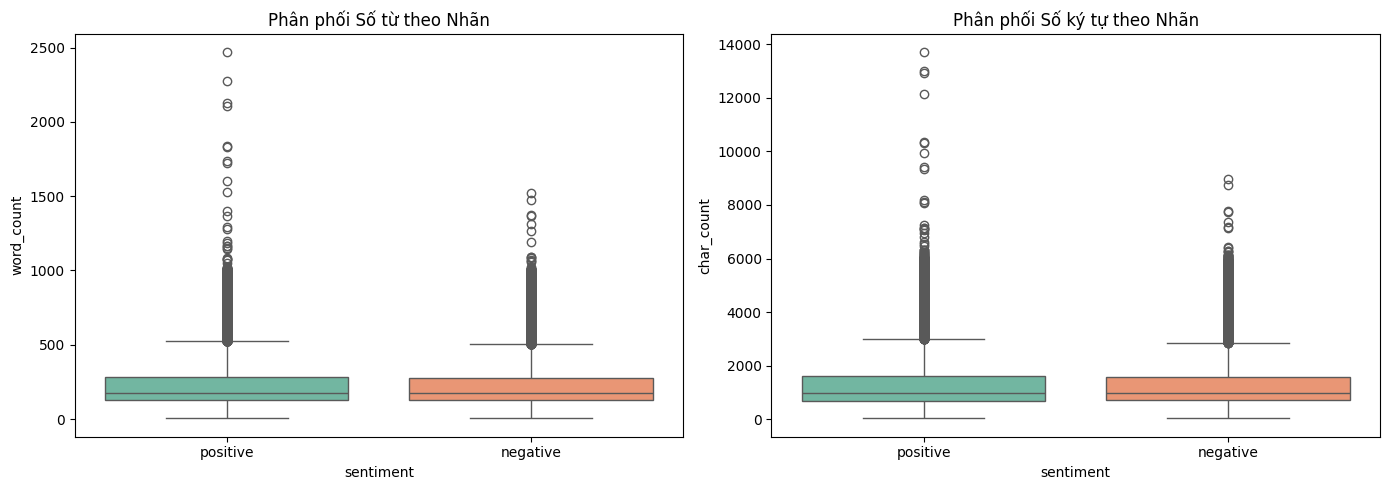

In [5]:
# 1. Tính toán số từ và số ký tự cho từng review

# Đếm số ký tự: Dùng thẳng hàm len() của chuỗi
df['char_count'] = df['review'].str.len()

# Đếm số từ: Cắt câu thành các từ, sau đó đếm số lượng từ đã cắt
df['word_count'] = df['review'].str.split().str.len()

# 2. Hiển thị bảng thống kê mô tả theo từng nhãn
print("--- Thống kê độ dài văn bản theo nhãn ---")
thong_ke = df.groupby('sentiment')[['word_count', 'char_count']].describe()
display(thong_ke)
# 3. Vẽ biểu đồ Boxplot để so sánh trực quan
# 3. Vẽ biểu đồ Boxplot để so sánh trực quan
plt.figure(figsize=(14, 5))

# Biểu đồ số từ
plt.subplot(1, 2, 1)
# Thêm hue='sentiment' và legend=False theo chuẩn mới của Seaborn
sns.boxplot(data=df, x='sentiment', y='word_count', hue='sentiment', palette='Set2', legend=False)
plt.title('Phân phối Số từ theo Nhãn')

# Biểu đồ số ký tự
plt.subplot(1, 2, 2)
# Thêm hue='sentiment' và legend=False theo chuẩn mới của Seaborn
sns.boxplot(data=df, x='sentiment', y='char_count', hue='sentiment', palette='Set2', legend=False)
plt.title('Phân phối Số ký tự theo Nhãn')

plt.tight_layout()
plt.show()

### Trả lời nhận xét Câu A2:

So sánh phân phối độ dài: Nhìn chung, độ dài văn bản giữa hai nhãn (Tích cực và Tiêu cực) là rất giống nhau. Tuy nhiên, nếu xét kỹ ở giá trị trung bình (Mean), nhãn positive (233 từ) nhỉnh hơn một chút xíu so với negative (229 từ). Bài đánh giá có độ dài "khủng" nhất trong tập dữ liệu cũng thuộc về nhãn Tích cực (2470 từ).

Độ dài văn bản có tương quan với nhãn phân loại không? Tại sao? Trong tập dữ liệu IMDB này, độ dài văn bản KHÔNG có sự tương quan đáng kể với nhãn.
Lý do: Tâm lý của con người khi viết bình luận phim ảnh thường khá giống nhau. Một người cực kỳ ghét bộ phim có thể viết một bài chê bai rất dài để chỉ ra từng lỗi kịch bản. Ngược lại, một người rất thích phim cũng có thể viết một bài phân tích dài không kém để khen ngợi diễn xuất và ý nghĩa. Do đó, độ dài (ngắn/dài) không giúp mô hình phân biệt được là họ đang khen hay chê. Mô hình buộc phải dựa vào ý nghĩa của các từ vựng cụ thể (như "tuyệt vời", "thảm họa", "đáng xem"...) chứ không thể dựa vào số lượng từ.

## Tiền sử lý văn bản


In [6]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Tải các bộ từ điển cần thiết của NLTK (chỉ tải nếu máy chưa có)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 2. Khởi tạo stopwords và lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Giữ lại các từ phủ định quan trọng
important_words = {'not', 'no', 'nor', 'but', 'against'}
stop_words = stop_words - important_words

# 3. Hàm tiền xử lý
def preprocess_text(text):
    # Chuyển chữ thường
    text = str(text).lower()
    
    # Xóa thẻ HTML (<br />)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Xóa link URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Xóa ký tự đặc biệt, dấu câu, số
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tách từ và loại bỏ stopwords + Lemmatization
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

# 4. Áp dụng vào DataFrame
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Tiền xử lý hoàn tất!")
display(df[['review', 'cleaned_review']].head())

Tiền xử lý hoàn tất!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


### Giải thích các bước xử lý dữ liệu:

**1. Chuyển toàn bộ văn bản về chữ thường (Lowercasing)**
* **Code áp dụng:** `text = str(text).lower()`
* **Lý do:** Đối với máy tính, ký tự viết hoa và viết thường có mã máy (ASCII/Unicode) khác nhau. Nếu không chuyển về chữ thường, máy tính sẽ coi "Movie", "MOVIE" và "movie" là 3 từ vựng hoàn toàn khác biệt.
* **Tác dụng:** Việc chuẩn hóa tất cả về chữ thường giúp đồng nhất dữ liệu, làm giảm đáng kể kích thước bộ từ vựng (vocabulary size) mà thuật toán phải học, từ đó giúp mô hình học nhanh hơn và khái quát hóa tốt hơn.

**2. Xóa các thẻ HTML (Removing HTML Tags)**
* **Code áp dụng:** `text = re.sub(r'<.*?>', ' ', text)`
* **Lý do:** Tập dữ liệu IMDB được thu thập (crawl) từ trang web, do đó trong các bài đánh giá có lẫn rất nhiều thẻ cấu trúc web, phổ biến nhất là thẻ ngắt dòng `<br />`. Các thẻ này chỉ có tác dụng hiển thị giao diện trên trình duyệt, hoàn toàn không mang bất kỳ giá trị ngôn ngữ hay cảm xúc nào.
* **Tác dụng:** Loại bỏ chúng để tránh làm nhiễu mô hình, không để mô hình học sai rằng `<br />` là một đặc trưng của nhận xét phim.

**3. Xóa đường dẫn liên kết (Removing URLs)**
* **Code áp dụng:** `text = re.sub(r'http\S+|www\S+|https\S+', '', text)`
* **Lý do:** Người dùng đôi khi dán link trailer phim hoặc link tham khảo vào bài đánh giá. Đối với máy tính, URL là một chuỗi ký tự ngẫu nhiên, dài và không có ý nghĩa về mặt ngữ nghĩa (ví dụ: `https://imdb.com/title/tt12345`).
* **Tác dụng:** Giống như thẻ HTML, việc xóa URL giúp làm sạch văn bản, loại bỏ các cụm ký tự vô nghĩa đối với bài toán phân loại sắc thái tình cảm.

**4. Xóa dấu câu, số và ký tự đặc biệt (Removing Punctuations & Numbers)**
* **Code áp dụng:** `text = re.sub(r'[^a-z\s]', ' ', text)` *(Chỉ giữ lại chữ cái từ a đến z và khoảng trắng)*
* **Lý do:** Các con số (1, 2, 3...) hay các dấu câu (!, ?, @, #, $, %, chấm, phẩy) trong đa số trường hợp không giúp ích nhiều cho việc xác định một bình luận là Tích cực hay Tiêu cực bằng các mô hình cơ bản (như Bag of Words hay TF-IDF).
* **Tác dụng:** Giúp tách các từ ra một cách rõ ràng nhất. Ví dụ: Từ "great!!!", "great," và "great" sau khi xóa dấu câu sẽ đều trở thành một từ duy nhất là "great".

**5. Tách từ (Tokenization) và Loại bỏ Từ dừng (Removing Stopwords)**
* **Code áp dụng:** `if word not in stop_words`
* **Lý do:** Từ dừng (Stopwords) là những từ xuất hiện với tần suất cực kỳ dày đặc trong câu nhưng chỉ đóng vai trò nối cấu trúc ngữ pháp (ví dụ: the, a, an, is, are, in, at...). Chúng không mang ý nghĩa quyết định xem câu đó là khen hay chê. Xóa chúng đi giúp mô hình tập trung 100% "sự chú ý" vào các từ khóa mang cảm xúc (như excellent, terrible, boring).
* **Giải thích ngoại lệ cực kỳ quan trọng:** Trong code, chúng ta đã cố tình giữ lại các từ mang nghĩa phủ định (như not, no, but). Lý do là vì chúng có khả năng đảo ngược hoàn toàn cực cảm xúc của câu. Nếu ta xóa từ "not", một câu chê bai như "This movie is not good" sẽ biến thành "movie good" (phim hay) – làm mô hình dự đoán sai hoàn toàn.

**6. Chuẩn hóa hình thái từ (Lemmatization)**
* **Code áp dụng:** `lemmatizer.lemmatize(word)`
* **Lý do:** Trong tiếng Anh, một từ có thể bị biến đổi thành nhiều dạng khác nhau phụ thuộc vào thì hoặc số nhiều (Ví dụ: Động từ: watch, watches, watched, watching / Danh từ: movie, movies).
* **Tác dụng:** Lemmatization sử dụng từ điển ngôn ngữ học để đưa tất cả các biến thể này về một dạng gốc duy nhất (gọi là Lemma). Quá trình này giúp máy tính hiểu rằng dù người dùng viết là watched hay watching thì ý nghĩa cốt lõi vẫn là hành động "xem". Điều này tiếp tục làm giảm số lượng từ vựng dư thừa, giúp không gian vector của mô hình nhỏ gọn và chính xác hơn.

## A3 Làm sạch văn bản

In [7]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Khởi tạo các công cụ
stop_words = set(stopwords.words('english'))
stop_words = stop_words - {'not', 'no', 'nor', 'but', 'against'} 
lemmatizer = WordNetLemmatizer()

# Hàm tiền xử lý (Câu A3)
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

# ==========================================
# PHẦN IN KẾT QUẢ RA MÀN HÌNH
# ==========================================

# 1. In thử nghiệm nghiệm trên 1 câu ví dụ để kiểm tra hàm:
sample_text = "I am watching this movie <br> again! It's NOT better than I thought. https://imdb.com"
print("Câu gốc   :", sample_text)
print("Sau xử lý :", preprocess_text(sample_text))
print("-" * 50)

# 2. Áp dụng vào toàn bộ DataFrame và in ra 5 dòng đầu tiên:
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("\n--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN TRONG DATAFRAME ---")
# Dùng thư viện IPython để in bảng cho đẹp trong file ipynb

display(df[['review', 'cleaned_review']].head())

Câu gốc   : I am watching this movie <br> again! It's NOT better than I thought. https://imdb.com
Sau xử lý : watching movie not better thought
--------------------------------------------------

--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN TRONG DATAFRAME ---


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


## Câu A4


In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bước phụ: Xử lý ngoại lệ (Phòng trường hợp có dòng bị rỗng NaN làm lỗi code)
df['cleaned_review'] = df['cleaned_review'].fillna("")

# Bag of Words (CountVectorizer)

# Khởi tạo mô hình CountVectorizer, giới hạn 10.000 từ xuất hiện nhiều nhất
bow_vectorizer = CountVectorizer(max_features=10000)

# Tiến hành học từ vựng và chuyển đổi văn bản thành ma trận
X_bow = bow_vectorizer.fit_transform(df['cleaned_review'])

print("[1] Bag of Words:")
print("    -> Kích thước ma trận X_bow:", X_bow.shape)
# (Ma trận sẽ có số dòng = số bài đánh giá, số cột = 10.000 từ vựng)

# TF-IDF

# Khởi tạo TfidfVectorizer, giới hạn 10.000 từ, ngram=(1,2) lấy cả từ đơn và cụm 2 từ
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Tiến hành học và chuyển đổi
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review'])

print("[2] TF-IDF:")
print("    -> Kích thước ma trận X_tfidf:", X_tfidf.shape)


[1] Bag of Words:
    -> Kích thước ma trận X_bow: (50000, 10000)
[2] TF-IDF:
    -> Kích thước ma trận X_tfidf: (50000, 10000)


### (a) So sánh TF-IDF và Bag of Words & Giải thích công thức TF-IDF

#### 1. Sự khác biệt giữa TF-IDF và Bag of Words (BoW):

* **Bag of Words (BoW):** Chỉ đơn thuần là đếm số lần xuất hiện của mỗi từ trong một văn bản. BoW đối xử với tất cả các từ một cách bình đẳng. 
  * *Ví dụ:* Nếu từ "movie" xuất hiện 50 lần, nó sẽ có trọng số rất cao. Tuy nhiên, trong bộ dữ liệu IMDB, từ "movie" xuất hiện ở mọi bài đánh giá và không giúp ích nhiều cho việc phân biệt lời khen hay tiếng chê.
* **TF-IDF:** Tinh tế hơn BoW rất nhiều. Nó không chỉ đếm số lần xuất hiện của từ trong một bài cụ thể, mà còn đánh giá mức độ hiếm gặp của từ đó trên toàn bộ tập dữ liệu. 
  * *Cơ chế:* TF-IDF sẽ phạt (giảm trọng số) những từ xuất hiện quá phổ biến ở mọi văn bản, và thưởng (tăng trọng số) cho những từ khóa đặc trưng, xuất hiện nhiều trong một bài đánh giá cụ thể nhưng hiếm khi xuất hiện ở các bài khác.

#### 2. Giải thích công thức TF-IDF theo cách hiểu đơn giản:

Công thức tổng quát: **TF-IDF = TF × IDF**

* **TF (Term Frequency - Tần suất từ):** Đo lường số lần một từ xuất hiện trong *một văn bản cụ thể*.
  * *Cách hiểu:* Nếu tôi viết một bài đánh giá và dùng từ "masterpiece" (kiệt tác) tới 5 lần, thì điểm TF của từ này trong bài của tôi rất cao. Điều này chứng tỏ bài viết của tôi rất có thể đang nói về sự xuất sắc.
* **IDF (Inverse Document Frequency - Tần suất nghịch văn bản):** Đo lường mức độ quan trọng/độ hiếm của từ đó trên *toàn bộ kho dữ liệu*. Công thức toán học là $\log \left( \frac{\text{Tổng số văn bản}}{\text{Số văn bản chứa từ đó}} \right)$.
  * *Cách hiểu:* Từ "movie" xuất hiện trong 49.000 / 50.000 bài đánh giá $\rightarrow$ Nó quá phổ biến, chẳng có gì đặc biệt $\rightarrow$ Điểm IDF sẽ cực kỳ thấp (gần bằng 0). Ngược lại, từ "masterpiece" chỉ xuất hiện trong 500 / 50.000 bài $\rightarrow$ Nó khá hiếm và mang tính phân loại cao $\rightarrow$ Điểm IDF sẽ rất cao.

> **Tóm tắt:** Một từ sẽ được hệ thống đánh giá là đặc trưng (điểm TF-IDF cao) NẾU nó xuất hiện lặp đi lặp lại rất nhiều lần trong một văn bản (TF cao), NHƯNG lại rất hiếm khi xuất hiện trong các văn bản khác của kho dữ liệu (IDF cao).

## A3


### Câu A6: Câu hỏi phân tích (Kiểm tra hiểu bài)

#### 1. Xác định vấn đề trong đoạn code của sinh viên X và đề xuất cách sửa

**Vấn đề (Lỗi sai nghiêm trọng):**
Sinh viên X đã sử dụng phương thức `fit_transform()` cho cả tập huấn luyện (`X_train`) và tập kiểm thử (`X_test`). Lỗi sai nằm ở dòng code thứ 3: 
`X_test_vec = vectorizer.fit_transform(X_test) 

* **Nguyên nhân lỗi:** Hàm `fit_transform` thực hiện hai việc: 
  1. `fit`: Học các từ vựng và xây dựng từ điển (vocabulary) từ dữ liệu truyền vào.
  2. `transform`: Chuyển đổi dữ liệu văn bản thành ma trận vector dựa trên từ điển vừa học. 
  
  Khi sinh viên dùng `fit_transform(X_test)`, hệ thống đã vứt bỏ bộ từ điển vừa học được ở tập Train và **xây dựng một bộ từ điển hoàn toàn mới** dựa trên tập Test. Điều này dẫn đến việc số lượng cột (features) và ý nghĩa của các cột ở tập Train và tập Test hoàn toàn khác nhau (không khớp nhau).

**Đề xuất cách sửa:**
Đối với tập kiểm thử (`X_test`), **chỉ được phép sử dụng hàm `transform()`** để chuyển đổi văn bản thành vector dựa trên bộ từ điển đã học từ tập Train trước đó.

```python
# Code sửa lại cho đúng:
vectorizer = TfidfVectorizer()

# Tập Train: Dùng fit_transform để học từ điển MỚI và chuyển đổi
X_train_vec = vectorizer.fit_transform(X_train)

# Tập Test: CHỈ DÙNG transform để áp dụng từ điển CŨ đã học từ tập Train
X_test_vec  = vectorizer.transform(X_test)



#### 2. Tại sao không được `fit` vectorizer trên tập test? Hậu quả là gì nếu làm vậy?

**Tại sao KHÔNG được phép `fit` trên tập test?**
Trong Machine Learning, có một nguyên tắc tối thượng: **Tập kiểm thử (Test set) phải là dữ liệu hoàn toàn xa lạ (unseen data)**. Tập Test đóng vai trò mô phỏng lại môi trường thực tế khi hệ thống AI đi vào hoạt động (nhận các dữ liệu mới tinh từ người dùng). 

Chức năng của hàm `fit` là học từ vựng (vocabulary) và các tham số thống kê từ tập dữ liệu. Nếu bạn gọi hàm `fit` trên tập Test, bạn đã vi phạm nguyên tắc trên vì vô tình cho phép mô hình "học trước" dữ liệu mà lẽ ra nó chỉ được phép dùng để làm bài thi. Do đó, quy trình đúng là: Chỉ được `fit` (học từ vựng) trên tập Train, và `transform` (áp dụng từ vựng đã học) để biến đổi tập Test.

**Hậu quả nếu làm sai (cố tình `fit_transform` trên tập Test):**

**1. Xảy ra lỗi lệch ma trận đặc trưng (Dimension & Feature Mismatch):**
Đây là lỗi kỹ thuật trực tiếp sẽ làm chương trình bị crash (dừng hoạt động). 
* Khi bạn `fit` trên tập Train, hệ thống tạo ra một bộ từ điển (ví dụ: 10.000 từ vựng). Ma trận đầu ra có 10.000 cột, giả sử cột số 1 là từ *"excellent"*.
* Khi bạn `fit` lại trên tập Test, hệ thống sẽ xóa từ điển cũ và tạo một bộ từ điển hoàn toàn mới dựa trên tập Test (ví dụ: chỉ có 8.000 từ vựng). Lúc này ma trận Test chỉ có 8.000 cột, và cột số 1 có thể bị đổi thành từ *"awful"*.
* **Hậu quả:** Thuật toán huấn luyện (như SVM, Naive Bayes...) đã quen với ma trận 10.000 cột của tập Train. Khi bạn đưa ma trận 8.000 cột của tập Test vào để yêu cầu dự đoán, thuật toán sẽ báo lỗi `ValueError` (không khớp số lượng đặc trưng) và không thể chạy được.

**2. Rò rỉ dữ liệu (Data Leakage) dẫn đến "ảo tưởng sức mạnh":**
Nếu bằng cách nào đó bạn ép số lượng cột khớp nhau nhưng sai từ vựng, mô hình đã bị "rò rỉ" thông tin. Nó sẽ học được tần suất xuất hiện của các từ khóa (TF-IDF) trực tiếp trên tập kiểm thử. Điều này khiến cho điểm số đánh giá mô hình (như Accuracy, F1-Score) cao một cách giả tạo. Khi bạn mang mô hình này triển khai vào thực tế với những dữ liệu thực sự mới, độ chính xác sẽ tụt thê thảm.

# Phần B: Trực quan hóa dữ liệu

## B1: Biểu đồ thống kê 

### B1: Biểu đồ thống kê phân phối nhãn

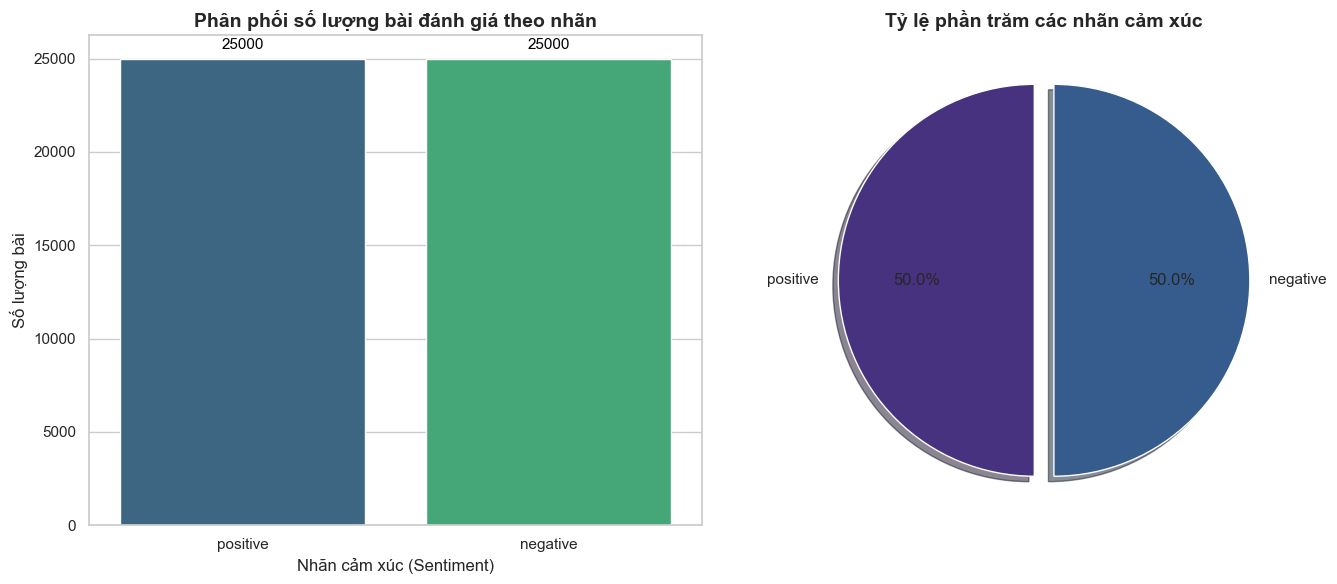

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Lấy dữ liệu đếm số lượng từng nhãn
label_counts = df['sentiment'].value_counts()

# 1. Vẽ Bar Chart (Biểu đồ cột) 
plt.subplot(1, 2, 1)
# Thêm hue=label_counts.index và legend=False theo chuẩn Seaborn mới
ax = sns.barplot(x=label_counts.index, y=label_counts.values, 
                 hue=label_counts.index, palette="viridis", legend=False)

plt.title('Phân phối số lượng bài đánh giá theo nhãn', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn cảm xúc (Sentiment)', fontsize=12)
plt.ylabel('Số lượng bài', fontsize=12)

# Hiển thị số lượng cụ thể trên đỉnh mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

# 2. Vẽ Pie Chart (Biểu đồ tròn)
plt.subplot(1, 2, 2)
colors = sns.color_palette("viridis")[0:len(label_counts)]
plt.pie(label_counts.values, labels=label_counts.index, colors=colors, 
        autopct='%1.1f%%', startangle=90, explode=[0.05]*len(label_counts), shadow=True)
plt.title('Tỷ lệ phần trăm các nhãn cảm xúc', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### Nhận xét biểu đồ phân phối nhãn
Qua hai biểu đồ Bar chart và Pie chart, ta có thể thấy rõ sự phân bổ của các nhãn cảm xúc trong tập dữ liệu:
* Dữ liệu được phân chia hoàn toàn cân bằng với tỷ lệ **50% Positive (Tích cực)** và **50% Negative (Tiêu cực)**. 
* Việc tập dữ liệu không bị mất cân bằng (Imbalanced dataset) là một điều kiện cực kỳ lý tưởng trong Machine Learning. Nó giúp đảm bảo mô hình phân loại khi huấn luyện sẽ không bị thiên lệch (bias) hay dự đoán nghiêng về phe chiếm đa số, từ đó cho ra các chỉ số đánh giá khách quan và chính xác nhất.


### Câu B2: Box plot phân phối độ dài văn bản

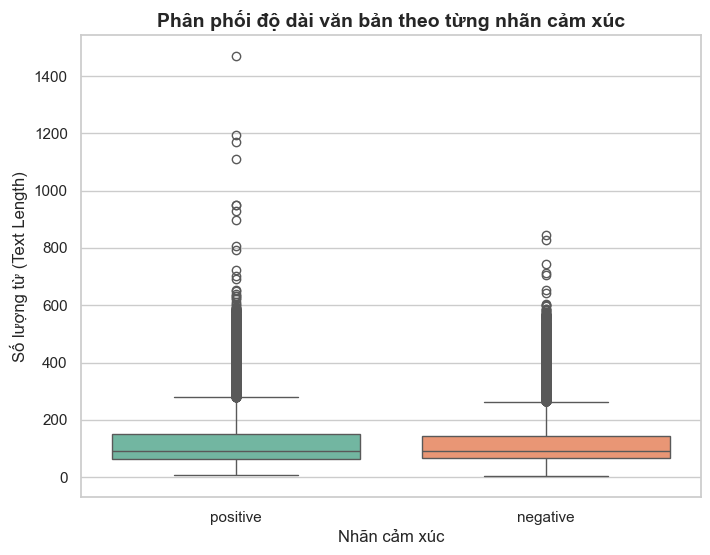

In [ ]:
#  Viết một hàm đếm số từ rõ ràng
def count_words(text):
    return len(str(text).split())

#  Áp dụng hàm vừa viết vào cột (không dùng lambda)
df['text_length'] = df['cleaned_review'].apply(count_words)

#  Vẽ Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment', y='text_length', data=df, 
            hue='sentiment', palette="Set2", legend=False)

plt.title('Phân phối độ dài văn bản theo từng nhãn cảm xúc', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn cảm xúc', fontsize=12)
plt.ylabel('Số lượng từ (Text Length)', fontsize=12)

plt.show()

#### Nhận xét Box plot phân phối độ dài văn bản
Biểu đồ Box plot giúp ta quan sát sự phân tán độ dài của các bài đánh giá giữa các nhãn:
* Nhìn chung, đường trung vị (median - đường kẻ ngang giữa hộp) của cả bài review tích cực và tiêu cực khá tương đồng nhau. Điều này chứng tỏ người dùng có xu hướng viết độ dài tương đương nhau cho dù họ khen hay chê.
* Điểm đáng chú ý là có rất nhiều **điểm ngoại lai (outliers)** xuất hiện phía trên râu (whisker) của cả hai biểu đồ. Điều này cho thấy có một bộ phận người dùng viết những bài đánh giá cực kỳ dài và tâm huyết (lên tới hàng ngàn từ) để phân tích bộ phim, bất kể sắc thái là khen hay chê.

## Câu B2: Phân tích từ ngữ

### Câu B4: Word Cloud

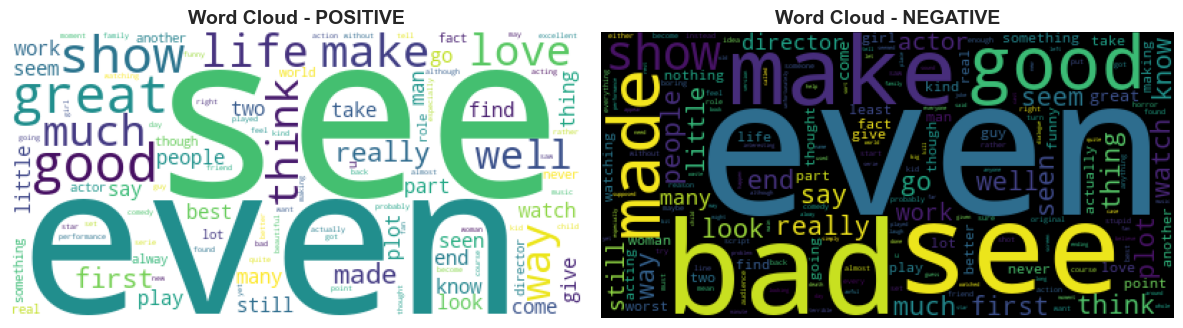

In [ ]:
# Lấy danh sách các nhãn hiện có trong dữ liệu (Vd: Positive, Negative...)
unique_labels = df['sentiment'].unique()

# Thiết lập kích thước đồ thị linh hoạt dựa trên số lượng nhãn
plt.figure(figsize=(16, 8))

for i, label in enumerate(unique_labels, 1):
    # Gom toàn bộ văn bản của nhãn hiện tại thành 1 chuỗi khổng lồ
    text_data = " ".join(review for review in df[df['sentiment'] == label]['cleaned_review'].astype(str))
    
    # Tạo Word Cloud với nền đen/trắng tương phản
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='black' if label == 'negative' else 'white', 
                          colormap='Reds' if label == 'negative' else 'viridis',
                          max_words=100).generate(text_data)
    
    # Vẽ lên subplot
    plt.subplot(1, len(unique_labels), i)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud - Nhãn: {label.upper()}', fontsize=16, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Nhận xét Đám mây từ vựng - Word Cloud
Dựa vào kích thước chữ trong biểu đồ đám mây từ vựng, ta thấy **có sự khác biệt rất rõ ràng và sắc nét về mặt từ vựng** giữa các nhãn:
* Ở nhãn **Positive (Tích cực)**, các từ xuất hiện to và nổi bật nhất mang đậm tính khen ngợi như: *"great", "best", "love", "excellent", "beautiful", "perfect"*.
* Ở nhãn **Negative (Tiêu cực)**, không gian bị chiếm lĩnh bởi các từ mang sắc thái chê bai, thất vọng như: *"bad", "worst", "terrible", "awful", "boring", "waste"*.
* **Kết luận:** Sự phân cực từ vựng rõ rệt này chứng minh rằng quá trình tiền xử lý văn bản ở phần trước (loại bỏ stopwords, lemmatization) đã hoạt động rất hiệu quả. Mô hình đã giữ lại được những "đặc trưng lõi" mang tính quyết định, tạo tiền đề cực kỳ thuận lợi để các thuật toán Machine Learning có thể phân loại văn bản với độ chính xác cao.